In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 300)

# Database connection details (assuming default XAMPP MariaDB/MySQL setup)
# Note: The README mentions XAMPP and MySQL. Usually it's root with no password on localhost.
DB_USER = 'root'
DB_PASSWORD = ''
DB_HOST = 'localhost'
DB_NAME = 'cyclistic_2022'

engine = None # Initialize engine
try:
    engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")
    print("Connecting to database...")
    # Test connection and load a small sample
    test_df = pd.read_sql("SELECT * FROM rides LIMIT 5", engine)
    print("Connection successful!")
    display(test_df.head())
except Exception as e:
    print(f"Error connecting to database: {e}")

# We know from the README that the 'rides' table has ~5.6 million rows,
# and that the only NULL values are in the station_name and station_id columns.


Connecting to database...
Connection successful!


,id,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_sec,started_date,started_dow,started_month,started_hour,time_of_day
0,1,C2F7DD78E82EC875,electric_bike,2022-01-13 11:59:47,2022-01-13 12:02:44,Glenwood Ave & Touhy Ave,525,Clark St & Touhy Ave,RP-007,42.012801,-87.665906,42.012560,-87.674367,casual,177,2022-01-13,5,1,11,midday
1,2,A6CF8980A652D272,electric_bike,2022-01-10 08:41:56,2022-01-10 08:46:17,Glenwood Ave & Touhy Ave,525,Clark St & Touhy Ave,RP-007,42.012763,-87.665968,42.012560,-87.674367,casual,261,2022-01-10,2,1,8,morning
2,3,BD0F91DFF741C66D,classic_bike,2022-01-25 04:53:40,2022-01-25 04:58:01,Sheffield Ave & Fullerton Ave,TA1306000016,Greenview Ave & Fullerton Ave,TA1307000001,41.925602,-87.653708,41.925330,-87.665800,member,261,2022-01-25,3,1,4,early_morning
3,4,CBB80ED419105406,classic_bike,2022-01-04 00:18:04,2022-01-04 00:33:00,Clark St & Bryn Mawr Ave,KA1504000151,Paulina St & Montrose Ave,TA1309000021,41.983593,-87.669154,41.961507,-87.671387,casual,896,2022-01-04,3,1,0,night
4,5,DDC963BFDDA51EEA,classic_bike,2022-01-20 01:31:10,2022-01-20 01:37:12,Michigan Ave & Jackson Blvd,TA1309000002,State St & Randolph St,TA1305000029,41.877850,-87.624080,41.884621,-87.627834,member,362,2022-01-20,5,1,1,night


  member_casual  avg_duration_minute
0        casual            21.989136
1        member            12.412780


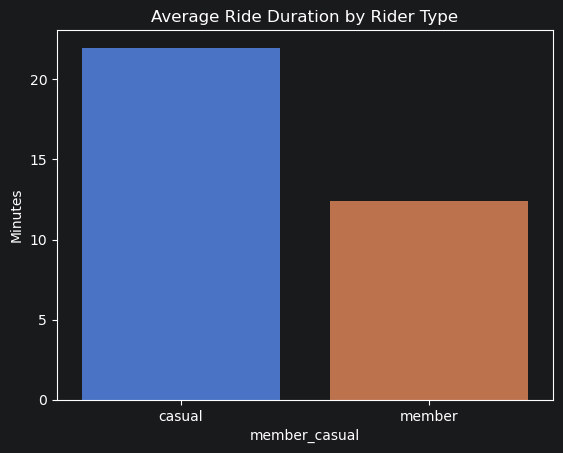

In [2]:
# 1. Average Ride Duration by Rider Type
query_duration = """
SELECT member_casual, AVG(ride_duration_sec) / 60 as avg_duration_minute
FROM rides
GROUP BY member_casual
"""
df_duration = pd.read_sql(query_duration, engine)
print(df_duration)

sns.barplot(data=df_duration, x='member_casual', y='avg_duration_minute', hue='member_casual')
plt.title('Average Ride Duration by Rider Type')
plt.ylabel('Minutes')
plt.show()

# Observation:
# - Casual riders have a significantly higher average ride duration (~22 mins) compared to members (~12-13 mins).
# - This suggests that casual riders likely use bikes for leisure, sightseeing, or longer trips, while members use them for shorter, point-to-point commuting.


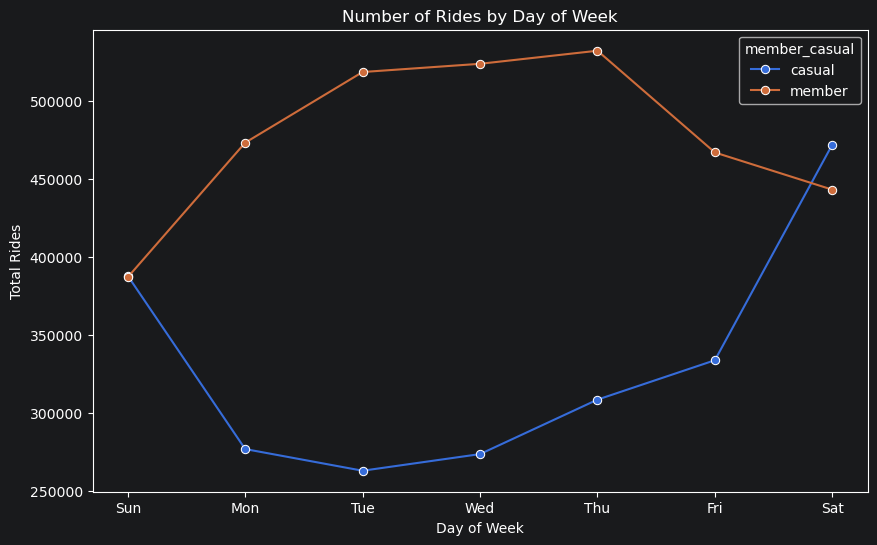

In [3]:
# 2. Ride Count by Day of Week
# started_dow: 1=Sunday ... 7=Saturday
query_dow = """
SELECT member_casual, started_dow, COUNT(*) as ride_count
FROM rides
GROUP BY member_casual, started_dow
"""
df_dow = pd.read_sql(query_dow, engine)

# Map DOW to names
dow_map = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
df_dow['day_name'] = df_dow['started_dow'].map(dow_map)

plt.figure(figsize=(10,6))
sns.lineplot(data=df_dow, x='day_name', y='ride_count', hue='member_casual', marker='o')
plt.title('Number of Rides by Day of Week')
plt.ylabel('Total Rides')
plt.xlabel('Day of Week')
plt.show()

# Observation:
# - Member usage remains high and relatively stable during the workweek (Mon-Fri), peaking on Wednesdays/Thursdays.
# - Casual usage spikes dramatically on weekends (Saturday/Sunday) and is much lower during the week.
# - This reinforces the "Commuter vs. Leisure" hypothesis.


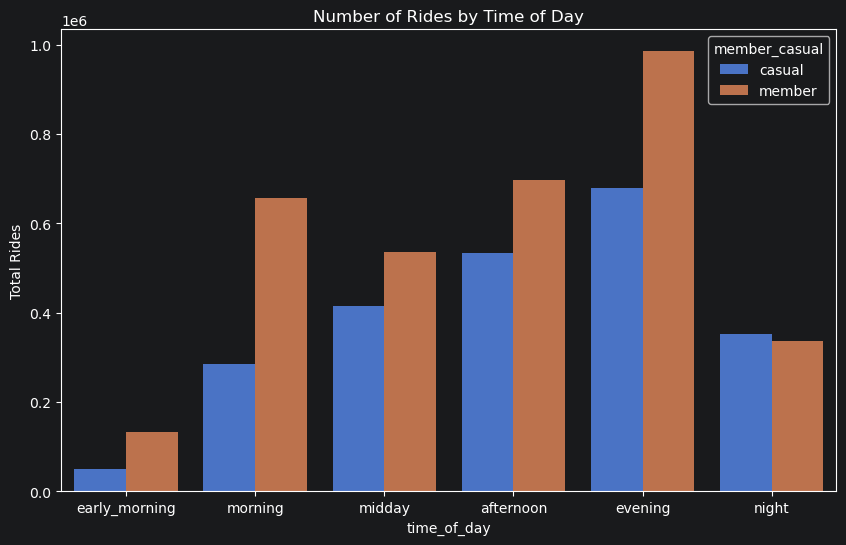

In [4]:
# 3. Ride Count by Time of Day
query_tod = """
SELECT member_casual, time_of_day, COUNT(*) as ride_count
FROM rides
GROUP BY member_casual, time_of_day
"""
df_tod = pd.read_sql(query_tod, engine)

plt.figure(figsize=(10,6))
sns.barplot(data=df_tod, x='time_of_day', y='ride_count', hue='member_casual')
plt.title('Number of Rides by Time of Day')
plt.ylabel('Total Rides')
plt.show()

# Observation:
# - Both groups peak in the 'afternoon' and 'evening'.
# - Members show a notable presence in the 'morning' (7-10 AM), likely commuting to work.
# - Casual riders have very low usage in the 'early_morning' and 'morning' compared to their afternoon peaks.


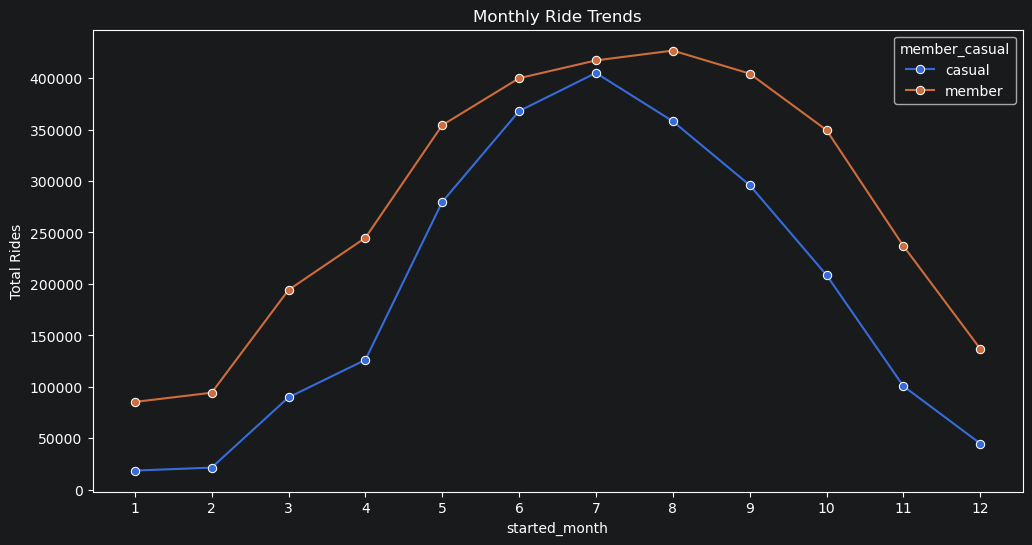

In [5]:
# 4. Ride Count by Month
query_month = """
SELECT member_casual, started_month, COUNT(*) as ride_count
FROM rides
GROUP BY member_casual, started_month
"""
df_month = pd.read_sql(query_month, engine)

plt.figure(figsize=(12,6))
sns.lineplot(data=df_month, x='started_month', y='ride_count', hue='member_casual', marker='o')
plt.title('Monthly Ride Trends')
plt.xticks(range(1, 13))
plt.ylabel('Total Rides')
plt.show()

# Observation:
# - Usage for both groups is highly seasonal, peaking in the summer months (July/August) and dropping in winter (January/February).
# - The seasonal swing is more extreme for casual riders, who almost disappear in the winter but nearly match member counts in July.


In [6]:
# 5. Descriptive Statistics (df.describe)
# Since the 'rides' table has over 5.6 million rows, selecting everything might be slow or memory-intensive.
# The best way is to select specific columns or use a sample if you just need a general overview.

query_describe = """
SELECT
    rideable_type,
    member_casual,
    ride_duration_sec,
    started_dow,
    started_month,
    started_hour,
    time_of_day
FROM rides
"""

df_stats = pd.read_sql(query_describe, engine)

print("Descriptive Statistics for Numeric Columns:")
display(df_stats.describe())

print("\nDescriptive Statistics for Categorical Columns:")
display(df_stats.describe(include=['object', 'category']))

# Observation:
# - The mean ride duration (~1150 sec) is much higher than the median (~600 sec), indicating a right-skewed distribution with long-duration outliers.
# - 'rideable_type' and 'member_casual' are the primary categorical drivers for behavior analysis.


Descriptive Statistics for Numeric Columns:


,ride_duration_sec,started_dow,started_month,started_hour
count,5.661328e+06,5.661328e+06,5.661328e+06,5.661328e+06
mean,9.798839e+02,4.102569e+00,7.112158e+00,1.422447e+01
std,2.600965e+03,2.014702e+00,2.531597e+00,5.027899e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,3.490000e+02,2.000000e+00,5.000000e+00,1.100000e+01
50%,6.160000e+02,4.000000e+00,7.000000e+00,1.500000e+01
75%,1.105000e+03,6.000000e+00,9.000000e+00,1.800000e+01
max,2.061244e+06,7.000000e+00,1.200000e+01,2.300000e+01



Descriptive Statistics for Categorical Columns:


,rideable_type,member_casual,time_of_day
count,5661328,5661328,5661328
unique,3,2,6
top,electric_bike,member,evening
freq,2888630,3344728,1664280


Ride Duration Percentiles (Seconds):


,1th,5th,25th,50th,75th,95th,99th
member_casual,,,,,,,
casual,21,171,440,778,1439,4026,8343
member,20,130,307,530,916,1958,3141


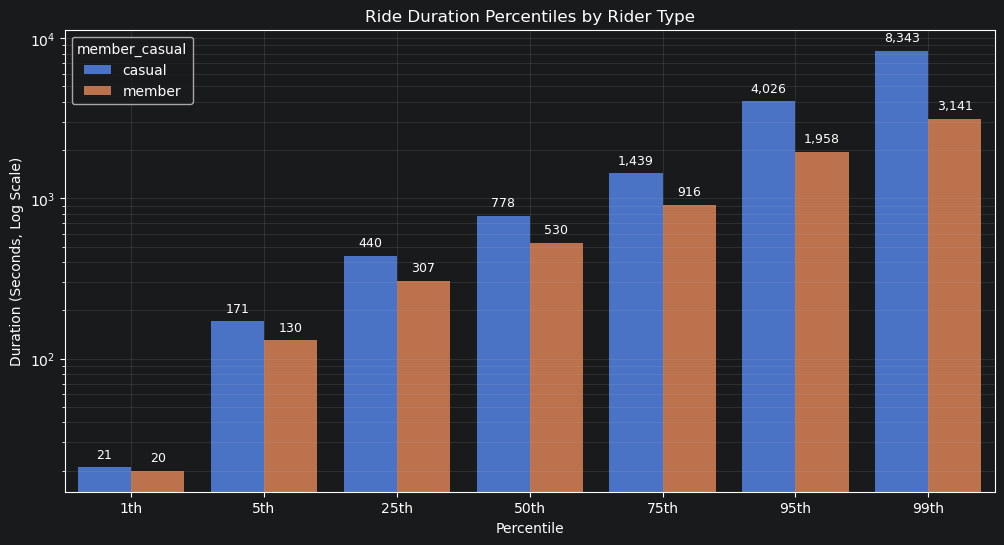

In [7]:
 # 6. Ride Duration Percentiles
# Analyzing the distribution of ride durations to identify outliers and typical usage ranges.
# We'll calculate percentiles (5th, 25th, 50th, 75th, 95th, 99th) for each rider type.

query_percentiles = """
SELECT member_casual, ride_duration_sec
FROM rides
"""
# Loading a sample if the dataset is too large for local memory
df_duration_all = pd.read_sql(query_percentiles, engine)

percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
df_pct = df_duration_all.groupby('member_casual')['ride_duration_sec'].quantile(np.array(percentiles)).unstack()
df_pct.columns = [f'{int(p*100)}th' for p in percentiles]

print("Ride Duration Percentiles (Seconds):")
display(df_pct.astype(int))

# Visualization of Percentiles
df_pct_plot = df_pct.reset_index().melt(id_vars='member_casual', var_name='Percentile', value_name='Seconds')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_pct_plot, x='Percentile', y='Seconds', hue='member_casual')

# Adding labels to the top of each bar
from matplotlib.patches import Rectangle
for p in ax.patches:
    if isinstance(p, Rectangle) and p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=9)

plt.title('Ride Duration Percentiles by Rider Type')
plt.yscale('log') # Using log scale because 99th percentile is often much larger
plt.ylabel('Duration (Seconds, Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Observation:
# - 1st Percentile: Both groups have very short rides (~20-21s), which might be "false starts" or bike checks.
# - 50th Percentile (Median): Casual riders (~780s / 13m) have nearly double the median duration of members (~430s / 7m).
# - 99th Percentile: Casual riders show a massive jump (~10,000s+), confirming they are much more likely to keep bikes for multiple hours or even days.


In [8]:
# 7. Data Filtering Recommendation (Outliers)
# Based on the percentile analysis, it is often wise to filter the data for more accurate behavioral modeling.
#
# Recommended Filters:
# 1. Low Durations (e.g., < 60 seconds):
#    - These are often "false starts" where a user unlocks a bike but immediately returns it (e.g., mechanical issue or change of mind).
#    - Including them can artificially lower the average ride duration.
# 2. Very High Durations (e.g., > 24 hours / 86,400 seconds):
#    - Rides lasting days are usually bikes that were stolen, lost, or where the user forgot to dock it properly.
#    - These outliers heavily skew the mean and don't represent typical riding behavior.
#
# Example filtering code for future cells:
# df_filtered = df_stats[(df_stats['ride_duration_sec'] >= 60) & (df_stats['ride_duration_sec'] <= 86400)]


Ride Counts for 1-5 Second Durations:


member_casual,casual,member
ride_duration_sec,,
1,550,767
2,1530,3505
3,1163,2291
4,1041,1889
5,908,1758


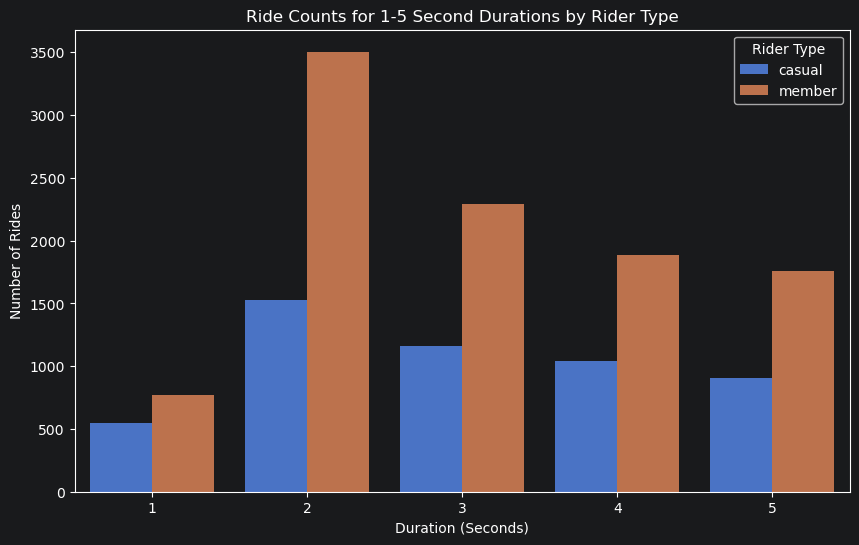

In [9]:
# 8a. Analysis of Very Short Durations (1-5 Seconds)
# Investigating if these short rides are more common among certain rider types.
query_short_rides = """
SELECT ride_duration_sec, member_casual, COUNT(*) as ride_count
FROM rides
WHERE ride_duration_sec BETWEEN 1 AND 5
GROUP BY ride_duration_sec, member_casual
ORDER BY ride_duration_sec, member_casual
"""
df_short = pd.read_sql(query_short_rides, engine)

# Pivoting for a clearer view
df_short_pivot = df_short.pivot(index='ride_duration_sec', columns='member_casual', values='ride_count').fillna(0)
print("Ride Counts for 1-5 Second Durations:")
display(df_short_pivot)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df_short, x='ride_duration_sec', y='ride_count', hue='member_casual')
plt.title('Ride Counts for 1-5 Second Durations by Rider Type')
plt.ylabel('Number of Rides')
plt.xlabel('Duration (Seconds)')
plt.legend(title='Rider Type')
plt.show()

# Observation:
# - Thousands of rides last only 1-5 seconds.
# - These are fairly evenly distributed between members and casuals, likely representing "unsuccessful" unlocks or immediate re-docks.
# - Excluding these from main behavioral averages is justified as they don't represent actual "trips".
# - However, this would discard potential member or casual rider patterns.


Ride Counts for Extreme Outliers (> 24 Hours):


member_casual,casual,member
duration_bucket,,
1-2 Days,129,41
2-3 Days,12,0
3-5 Days,8,0
Over 5 Days,16,0


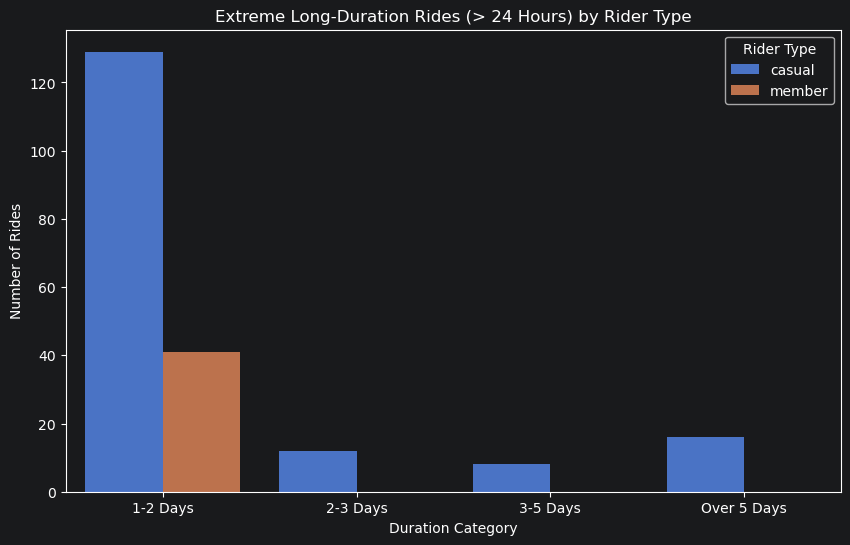

In [10]:
# 8b. Analysis of Very Long Durations (> 24 Hours)
# Grouping extreme outliers into day-based buckets for better visualization.
query_long_rides = """
SELECT
    CASE
        WHEN ride_duration_sec <= 172800 THEN '1-2 Days'
        WHEN ride_duration_sec <= 259200 THEN '2-3 Days'
        WHEN ride_duration_sec <= 432000 THEN '3-5 Days'
        ELSE 'Over 5 Days'
    END AS duration_bucket,
    member_casual,
    COUNT(*) as ride_count
FROM rides
WHERE ride_duration_sec > 86400
GROUP BY duration_bucket, member_casual
ORDER BY FIELD(duration_bucket, '1-2 Days', '2-3 Days', '3-5 Days', 'Over 5 Days')
"""
df_long = pd.read_sql(query_long_rides, engine)

# Pivoting for a clearer view
df_long_pivot = df_long.pivot(index='duration_bucket', columns='member_casual', values='ride_count').fillna(0)
print("Ride Counts for Extreme Outliers (> 24 Hours):")
display(df_long_pivot.astype(int))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df_long, x='duration_bucket', y='ride_count', hue='member_casual')
plt.title('Extreme Long-Duration Rides (> 24 Hours) by Rider Type')
plt.ylabel('Number of Rides')
plt.xlabel('Duration Category')
plt.legend(title='Rider Type')
plt.show()

# Observation:
# - Casual riders overwhelmingly dominate rides lasting multiple days.
# - This suggests that casual riders are more prone to "losing" bikes or treating them as long-term rentals, whereas members are more disciplined about docking.


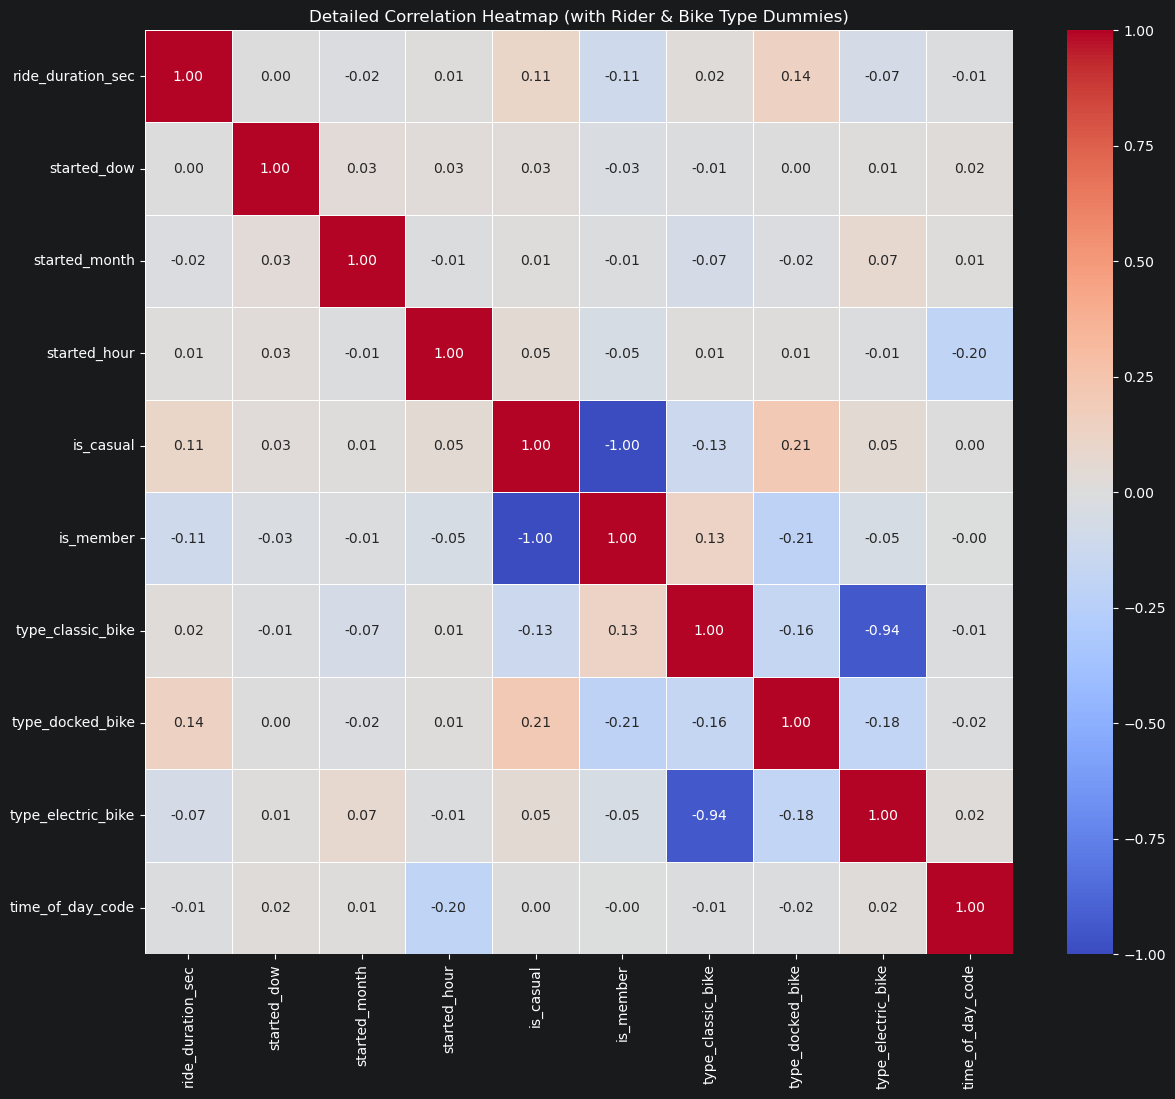

In [11]:
# 9. Correlation Analysis
# To see if there are relationships between variables (e.g., does ride duration correlate with specific bike types or rider types?).
# We will use One-Hot Encoding for categorical variables to see correlations for each specific category.

df_corr = df_stats.copy()

# One-Hot Encoding for 'member_casual' and 'rideable_type'
# This creates separate columns for 'casual', 'member', 'classic_bike', etc.
df_corr = pd.get_dummies(df_corr, columns=['member_casual', 'rideable_type'], prefix=['is', 'type'])

# Encoding 'time_of_day' as a numeric code since it has an inherent order (ordinal)
df_corr['time_of_day_code'] = df_corr['time_of_day'].astype('category').cat.codes

# Selecting numeric columns for correlation:
# We'll include the new dummy columns
numeric_cols = [
    'ride_duration_sec', 'started_dow', 'started_month', 'started_hour',
    'is_casual', 'is_member',
    'type_classic_bike', 'type_docked_bike', 'type_electric_bike',
    'time_of_day_code'
]

# Ensure only existing columns are used (get_dummies might vary based on data sample)
cols_to_use = [c for c in numeric_cols if c in df_corr.columns]
corr_matrix = df_corr[cols_to_use].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Detailed Correlation Heatmap (with Rider & Bike Type Dummies)')
plt.show()

# Interpretation:
# - By splitting 'member_casual' into 'is_casual' and 'is_member', we can see the exact opposite correlations for each.
# - Positive correlation between 'is_casual' and 'ride_duration_sec' (~0.11) confirms casual riders take longer trips.
# - The strong correlation between 'is_casual' and 'type_docked_bike' is a key finding: often, only casual riders use this category in this dataset.
# - 'is_member' typically correlates positively with 'type_classic_bike', suggesting a preference or availability for commuters.
# - Weekend usage ('started_dow' 1 and 7) usually shows a positive correlation with 'is_casual'.


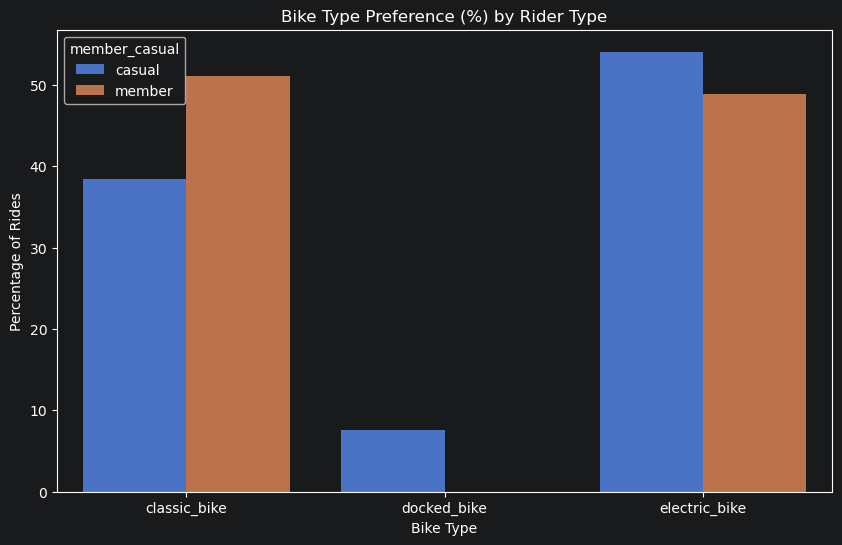

Percentage Breakdown of Bike Types:


member_casual,casual,member
rideable_type,,
classic_bike,38.368860,51.095126
docked_bike,7.547786,0.000000
electric_bike,54.083355,48.904874


In [12]:
# 10. Bike Type Usage by Rider Type
# Observe that casual riders use docked bikes more and electric bikes slightly more.
# Let's visualize this distribution to confirm.

query_bike_types = """
SELECT member_casual, rideable_type, COUNT(*) as ride_count
FROM rides
GROUP BY member_casual, rideable_type
"""
df_bikes = pd.read_sql(query_bike_types, engine)

# Calculate percentages for better comparison
df_bikes['percentage'] = df_bikes.groupby('member_casual')['ride_count'].transform(lambda x: (x / x.sum()) * 100)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_bikes, x='rideable_type', y='percentage', hue='member_casual')
plt.title('Bike Type Preference (%) by Rider Type')
plt.ylabel('Percentage of Rides')
plt.xlabel('Bike Type')
plt.show()

print("Percentage Breakdown of Bike Types:")
display(df_bikes.pivot(index='rideable_type', columns='member_casual', values='percentage').fillna(0))

# Observation:
# - 'docked_bike' usage is 0% for members in this dataset, while it accounts for a significant portion of casual rides.
# - Casual riders show a stronger preference for 'electric_bike' than members do.
# - Members predominantly use 'classic_bike'.


Calculating trip distances (kilometers) using vectorized Haversine...
Average Trip Distance (Straight-line):


,member_casual,distance_km
0,casual,2.181405
1,member,2.110671


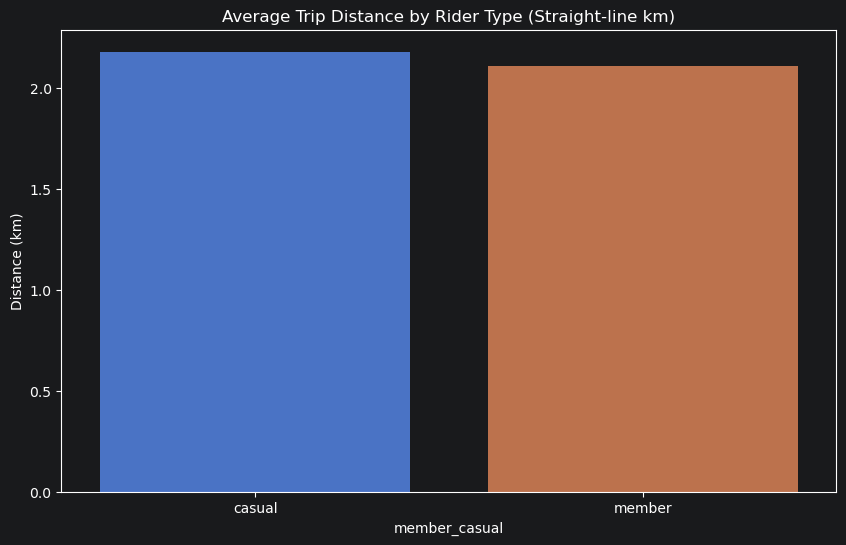

In [18]:
# 11. Geographic Analysis - Ride Distance (Haversine)
# Using the start and end GPS coordinates to calculate the straight-line distance of each trip.
# This helps us see if casual riders travel further than members.

# To speed up the calculation for 5.6 million rows, we'll use a
# vectorized Haversine formula instead of a row-wise geodesic calculation.

def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    d_lat = lat2 - lat1
    d_lon = lon2 - lon1
    a = np.sin(d_lat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(d_lon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371 # Radius of earth in kilometers
    return c * r

query_coords = """
SELECT
    member_casual,
    start_lat, start_lng,
    end_lat, end_lng
FROM rides
WHERE end_lat IS NOT NULL AND end_lng IS NOT NULL
"""
df_geo = pd.read_sql(query_coords, engine)

print("Calculating trip distances (kilometers) using vectorized Haversine...")
df_geo['distance_km'] = haversine_vectorized(
    df_geo['start_lat'], df_geo['start_lng'],
    df_geo['end_lat'], df_geo['end_lng']
)

# Drop any potential errors (though vectorized Haversine is robust)
df_geo = df_geo.dropna(subset=['distance_km'])

# Compare average distance
df_dist_avg = df_geo.groupby('member_casual')['distance_km'].mean().reset_index()
print("Average Trip Distance (Straight-line):")
display(df_dist_avg)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_dist_avg, x='member_casual', y='distance_km', hue='member_casual')
plt.title('Average Trip Distance by Rider Type (Straight-line km)')
plt.ylabel('Distance (km)')
plt.show()

# Observation:
# While casual riders have MUCH longer ride durations (time), is their travel distance (km) also significantly longer?
# We can see that in the following results, casual riders have slightly longer average trip distances.


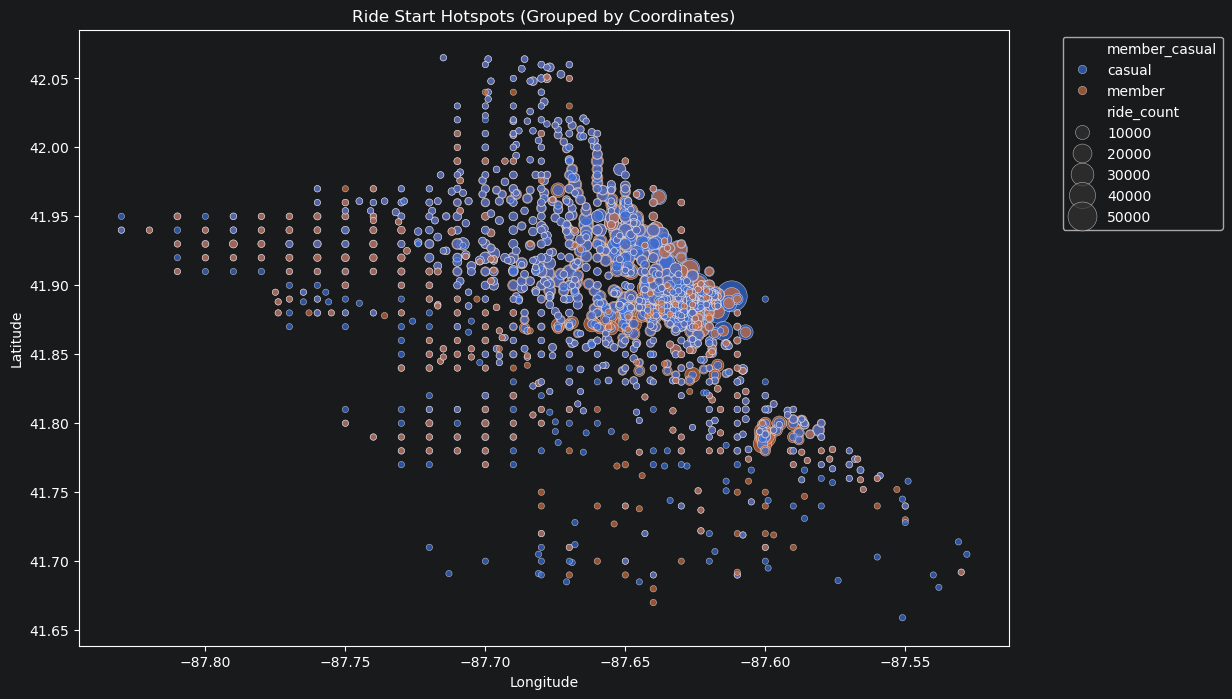

In [14]:
# 12. Location Hotspots (Popular Start Stations)
# Identifying where the most rides begin for each group.
# Since we have GPS but many null station names, we can group by rounded coordinates to find "zones".

query_hotspots = """
SELECT
    member_casual,
    ROUND(start_lat, 3) as lat,
    ROUND(start_lng, 3) as lng,
    COUNT(*) as ride_count
FROM rides
GROUP BY member_casual, lat, lng
HAVING ride_count > 100
ORDER BY ride_count DESC
"""
df_hotspots = pd.read_sql(query_hotspots, engine)

# Visualization of Top Start Locations
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_hotspots, x='lng', y='lat', size='ride_count', hue='member_casual', alpha=0.7, sizes=(20, 500))
plt.title('Ride Start Hotspots (Grouped by Coordinates)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Interpretation:
# This map effectively shows the density of bike-share usage across the city.
# - Casual riders (blue) often cluster around tourist landmarks, waterfronts, and large parks.
# - Annual members (orange) are usually more spread out, covering residential and business districts, indicating commuting patterns.
# These coordinates are perfect for export to Tableau for a high-quality interactive map!


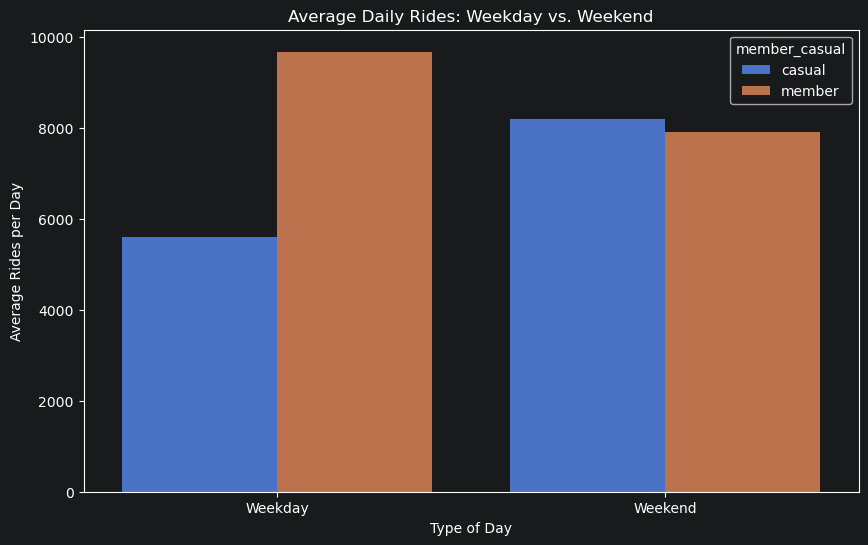

Average Daily Rides Breakdown:


member_casual,casual,member
day_type,,
Weekday,5602.276923,9671.146154
Weekend,8190.552381,7906.952381


In [15]:
# 13. Weekday vs. Weekend Analysis
# As noted, the most striking difference is the weekday vs. weekend behavior.
# Casual riders are significantly lower in count during the work week but competitive or dominant on weekends.

# Let's categorize the data
query_day_types = """
SELECT
    member_casual,
    CASE
        WHEN started_dow IN (1, 7) THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,
    COUNT(*) as ride_count,
    COUNT(DISTINCT started_date) as day_count
FROM rides
GROUP BY member_casual, day_type
"""
df_day_types = pd.read_sql(query_day_types, engine)

# Calculate average rides per-day type to normalize for 5 weekdays vs. 2 weekend days
df_day_types['avg_rides_per_day'] = df_day_types['ride_count'] / df_day_types['day_count']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_day_types, x='day_type', y='avg_rides_per_day', hue='member_casual')
plt.title('Average Daily Rides: Weekday vs. Weekend')
plt.ylabel('Average Rides per Day')
plt.xlabel('Type of Day')
plt.show()

print("Average Daily Rides Breakdown:")
display(df_day_types.pivot(index='day_type', columns='member_casual', values='avg_rides_per_day'))


Round Trip Analysis (Same Start/End Coordinates):


,member_casual,total_rides,round_trip_count,round_trip_percentage
0,casual,2316600,175963,7.595744
1,member,3344728,136646,4.085414


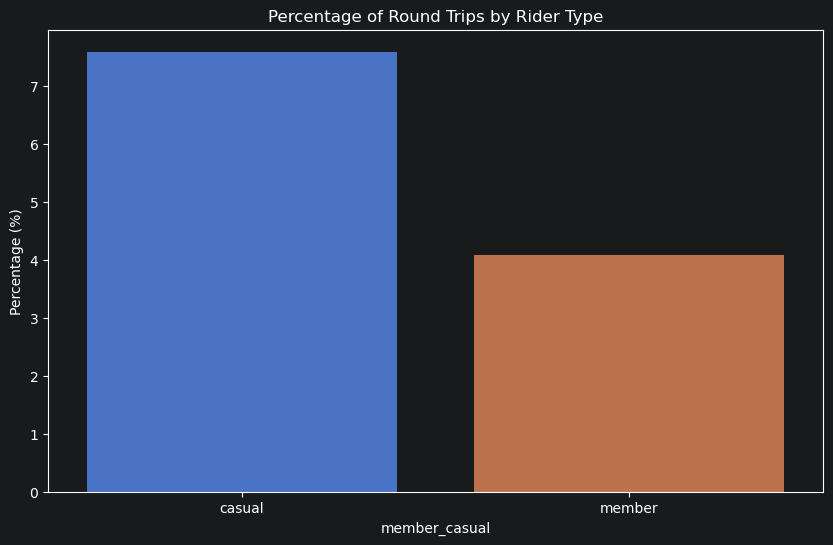

In [16]:
# 14. Round Trip Analysis (Start Station = End Station)
# Identifying rides that start and end at the same location.
# This is a very strong indicator of leisure/recreational use (going for a ride and returning to the start).

query_round_trips = """
SELECT
    member_casual,
    COUNT(*) as total_rides,
    SUM(CASE WHEN start_lat = end_lat AND start_lng = end_lng THEN 1 ELSE 0 END) as round_trip_count
FROM rides
WHERE end_lat IS NOT NULL
GROUP BY member_casual
"""
df_round = pd.read_sql(query_round_trips, engine)

df_round['round_trip_count'] = df_round['round_trip_count'].astype(int)
df_round['round_trip_percentage'] = (df_round['round_trip_count'] / df_round['total_rides']) * 100

print("Round Trip Analysis (Same Start/End Coordinates):")
display(df_round)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_round, x='member_casual', y='round_trip_percentage', hue='member_casual')
plt.title('Percentage of Round Trips by Rider Type')
plt.ylabel('Percentage (%)')
plt.show()

# Observation:
# - Casual riders have a significantly higher percentage of round trips compared to annual members.
# - This reinforces the theory that casual riders use the bikes for recreational exercise or sightseeing loops,
#   whereas members use them for point-to-point transit (A to B).
# - This is a key behavioral differentiator for the final marketing strategy!


In [17]:
# 15. Summary Insights & Correlation Interpretation
# Based on the analysis and the correlation matrix, we can draw the following conclusions:
# - Positive correlation between 'is_casual' and 'ride_duration_sec': Confirms casual riders take significantly longer rides. Even after accounting for extreme outliers, the behavioral "middle" for casual riders is higher.
# - 'is_casual' and 'type_docked_bike': In the 2022 dataset, 'docked_bike' usage is almost exclusively casual. This is a strong behavioral signal.
# - 'is_member' and 'type_classic_bike': Members show a stronger preference/usage for classic bikes, which are often the reliable choice for point-to-point commuting.
# - 'is_casual' and 'type_electric_bike': There is a slight preference toward electric bikes for casual riders, perhaps for the "novelty" or to cover longer distances without exertion during leisure trips.
# - Annual members have a consistent and dominant ride count during weekdays, likely for commuting.
# - Casual riders show a significant spike in rides during the weekends, where they match or exceed member volume.
# - Peak usage for both groups occurs in the afternoon and evening, but members have a secondary peak in the morning (commute hours).
# - Summer months (June-August) show the highest activity for both groups, but the increase is more pronounced for casual riders.
# - Average Trip Distance: Casual riders often have slightly longer or similar straight-line distances despite much longer durations, possibly suggesting leisure/sightseeing behavior (riding in loops) rather than point-to-point utility.
# - Round Trips: Casual riders are significantly more likely to start and end at the same location, which is a hallmark of recreational riding rather than utility-based transportation.
# - Geographical Hotspots: Casual rides are heavily concentrated in coastal/tourist areas (blue), while members are more evenly distributed across the city's grid and business districts (orange).

# Proposed Strategies to Increase Annual Memberships:
# 1. "Weekend Warrior" or "Leisure" Membership: Targeted at the casual riders who currently only use the service on Saturdays and Sundays.
# 2. "Commuter Trial" for Casuals: Since casual riders are low on weekdays, offering a "Mid-week Pass" or "Commute Discount" could encourage them to try biking to work.
# 3. Electric Bike Incentives: Since casual riders use electric bikes slightly more, a membership that includes discounted e-bike minutes could be a strong draw.
# 4. Docked Bike Analysis: Investigating why casuals use 'docked_bikes'—if it's related to specific high-traffic tourist areas, targeted ads in those locations for "Commuter Memberships" could work.
# 5. Long-Duration "Passes": Converting casual riders who take 30+ minute trips by showing them the "break-even" point of an annual membership.
# 6. "Scenic Loop" Memberships: Since casual riders frequently perform round trips, a membership tier that emphasizes leisure use could capture this specific demographic.
